<a href="https://colab.research.google.com/github/thiagopereiramagalhaes/Otimizacao_de_Classificacao_com_PCA-Selecao_de_Features_k-NN-Validacao_Cruzada/blob/main/Otimiza%C3%A7%C3%A3o_de_Classifica%C3%A7%C3%A3o_com_PCA%2C_Sele%C3%A7%C3%A3o_de_Features_e_k_NN_Uma_An%C3%A1lise_Comparativa_com_Valida%C3%A7%C3%A3o_Cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Otimização de Classificação com PCA, Seleção de Features e k-NN: Uma Análise Comparativa com Validação Cruzada

## Importar bibliotecas
** Importe pandas, seaborn e as bibliotecas usuais. **

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline

# Usando o algoritmo PCA para diminuir a dimensionalidade



1.   Gere uma base de dados com make_classification (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html#sklearn.datasets.make_classification)
4.   Faça a separação em treino e teste
5.   Utilize o algoritmo PCA https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA e gere mais dois conjuntos de dados com 10 e 5 features, além dos dados originais
6.   Treine modelos de k-NN com os dados originais e os dados gerados pelo PCA
6.   Analise os resultados


In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=0,
    shuffle=False,
)

# Divisão treino-teste

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,2.745723,0.434987,0.200510,-0.859013,1.031339,1.533685,0.359002,0.843508,-0.231170,0.211969,-1.196416,-0.614251,-1.282114,1.581893,-0.365299,-0.988581,-0.517450,0.878505,-0.155805,-0.568063
1,2.492135,0.447042,-0.128569,-0.685946,-0.656584,1.055098,0.692797,-0.132318,0.989101,-0.816751,0.536878,1.030478,-1.444788,0.327308,-0.440105,1.145424,-0.892054,1.485980,-0.571533,0.205845
2,-0.639933,0.421688,-1.188282,1.534097,-0.246998,1.411096,-1.056186,-0.542787,-2.301618,1.369763,0.924362,0.517899,-0.198598,-0.324507,-0.247557,-0.359112,-1.835627,-0.120767,0.109662,-2.347570
3,-0.680862,0.166283,-1.670551,-1.484819,-1.544481,0.374237,-2.306583,0.580127,-0.171613,-0.077598,0.733828,0.084314,-0.575797,-0.405408,0.080532,-0.404780,-1.359130,0.446435,-0.963825,-0.231652
4,-1.665712,1.761282,-0.950695,0.597816,-0.711291,-0.071337,-0.420740,1.012539,-0.735230,-0.251746,0.247126,1.256004,1.285379,1.196979,1.085299,-0.229643,0.515127,2.033205,-1.145093,-2.857502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,-0.817589,2.090871,1.440323,-2.387848,-1.382684,1.407806,0.893253,0.773753,0.239813,0.437557,-1.221188,-1.332439,1.439627,-0.981529,1.414650,0.459881,-0.402684,1.211106,-0.257970,-0.015998
696,4.276609,-0.163268,0.709086,-0.252772,-1.356073,0.948667,0.010327,0.755545,0.949951,-1.830156,0.775856,-0.116542,-0.207736,-0.596535,-0.669342,-0.372979,-1.467278,-1.536609,-1.124829,-0.225748
697,1.140908,-0.279668,0.989253,1.016580,-0.914312,-0.026333,-1.553405,0.205869,-0.583587,-0.680542,-0.058653,1.640477,-0.062165,-1.113475,-0.026230,-1.144036,1.654555,-0.022902,-0.947757,0.088687
698,-1.235688,-0.967674,1.322820,1.202772,0.275347,0.456219,0.062084,-2.091237,-1.546221,-1.692583,-0.914346,0.942656,-0.163268,-1.111465,-0.568969,-0.841628,1.508758,0.127082,-0.912377,-1.341265


## Utilizando o algoritmo PCA

In [ ]:
from sklearn.decomposition import PCA

Com 10 features

In [ ]:
pca10 = PCA(n_components=10)
pca10.fit(x_train)

PCA(n_components=10)

In [ ]:
x_pca10_train = pca10.transform(x_train)
x_pca10_test = pca10.transform(x_test)

Com 5 features

In [ ]:
pca5 = PCA(n_components=5)
pca5.fit(x_train)

PCA(n_components=5)

In [ ]:
x_pca5_train = pca5.transform(x_train)
x_pca5_test = pca5.transform(x_test)

## Treinando os modelos com todas as features, com 10 e 5 features do PCA

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

Todas as features

In [ ]:
knn_original = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn_original.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_original = knn_original.predict(x_test)

10 features geradas pelo PCA

In [ ]:
knn_pca10 = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn_pca10.fit(x_pca10_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_pca10 = knn_pca10.predict(x_pca10_test)

5 features geradas pelo PCA

In [ ]:
knn_pca5 = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn_pca5.fit(x_pca5_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_pca5 = knn_pca5.predict(x_pca5_test)

## Analisando os resultados dos experimentos

* O uso do PCA com 5 componentes obteve a melhor performance (Accuracy de 0.79), superando levemente o modelo com todas as 20 features originais (0.78), o que sugere que a redução eliminou ruídos dos dados.
* A validação cruzada confirmou a robustez dos modelos, especialmente no dataset Iris, onde a acurácia média atingiu 97.33%, validando que a simplificação do espaço de atributos, quando bem executada, mantém ou até melhora a capacidade de generalização do k-NN.

Com todas as features

In [ ]:
print(classification_report(y_test, pred_original))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76       133
           1       0.81      0.78      0.80       167

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300



10 features geradas pelo PCA

In [ ]:
print(classification_report(y_test, pred_pca10))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73       133
           1       0.79      0.80      0.79       167

    accuracy                           0.77       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.77      0.77      0.77       300



5 features geradas pelo PCA

In [ ]:
print(classification_report(y_test, pred_pca5))

              precision    recall  f1-score   support

           0       0.78      0.73      0.75       133
           1       0.79      0.83      0.81       167

    accuracy                           0.79       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.79      0.79      0.79       300



## Obtenha os dados
** Leia o arquivo csv 'Arvore_Decisao_Iris_Data.csv' em um DataFrame **

In [ ]:
df = pd.read_csv('Arvore_Decisao_Iris_Data.csv')

In [ ]:
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

In [ ]:
df.columns = columns

Convertendo o target em labels numérica

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class_numero'] = le.fit_transform(df['class'])

In [ ]:
df.drop('class', axis=1, inplace=True)

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class_numero
0,4.9,3.0,1.4,0.2,0
1,4.7,3.2,1.3,0.2,0
2,4.6,3.1,1.5,0.2,0
3,5.0,3.6,1.4,0.2,0
4,5.4,3.9,1.7,0.4,0


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,class_numero
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.848322,3.051007,3.774497,1.205369,1.006711
std,0.828594,0.433499,1.759651,0.761292,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.400000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Divisão treino-teste

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_iris = df.drop('class_numero', axis=1)
y_iris = df['class_numero']
x_train_i, x_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.3, random_state=101)

# Normalização as variáveis

Hora de para padronizar as variáveis.

Import StandardScaler do Scikit-learn.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

Converta as variáveis independentes com o StandardScaler

In [ ]:
scaler.fit(x_train_i)

StandardScaler()

Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [ ]:
x_train_scaled = scaler.transform(x_train_i)
x_test_scaled = scaler.transform(x_test_i)

# Usando o algoritmo Random Forest como Feature Selection

Importe o RandomForestClassfier e SelectFromModel do scikit learn.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import accuracy_score

In [ ]:
clf = RandomForestClassifier()

In [ ]:
clf.fit(x_train_scaled, y_train_i)

RandomForestClassifier()

In [ ]:
pred_rf = clf.predict(x_test_scaled)

Analisando a accuracy:

In [ ]:
print(accuracy_score(y_test_i, pred_rf))

0.9333333333333333


In [ ]:
importances = clf.feature_importances_
print(importances)

[0.10990391 0.02224918 0.40341477 0.46443214]


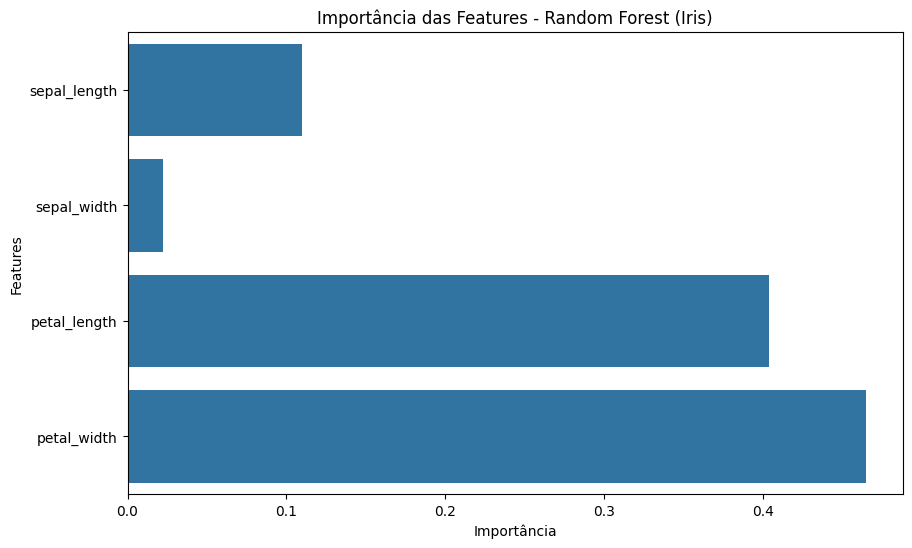

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=X_iris.columns)
plt.title('Importância das Features - Random Forest (Iris)')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()

Referência: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

## Utilizando e analisando feature selection do modelo Random Forest via SelectFromModel (sklearn)

In [ ]:
selector = SelectFromModel(clf, prefit=True)
selector.transform(x_train_scaled)

array([[ 9.96692644e-01,  1.08356062e+00],
       [-4.42974508e-01, -1.68553875e-01],
       [ 5.53718136e-02, -1.68553875e-01],
       [-1.05206446e+00, -1.29545692e+00],
       [-1.16280808e+00, -1.04503402e+00],
       [ 4.42974508e-01,  3.32291924e-01],
       [ 1.38429534e+00,  7.07926273e-01],
       [-1.66115441e-01, -2.93765324e-01],
       [-1.38429534e+00, -1.29545692e+00],
       [-1.38429534e+00, -1.17024547e+00],
       [ 4.42974508e-01,  2.07080475e-01],
       [-1.27355171e+00, -1.29545692e+00],
       [ 6.09089949e-01,  3.32291924e-01],
       [ 1.10743627e+00,  1.20877207e+00],
       [ 6.64461763e-01,  9.58349173e-01],
       [ 9.41320830e-01,  7.07926273e-01],
       [ 4.42974508e-01,  8.18690248e-02],
       [ 9.96692644e-01,  1.45919497e+00],
       [ 1.66115441e-01,  8.18690248e-02],
       [-1.27355171e+00, -1.04503402e+00],
       [ 3.87602695e-01,  3.32291924e-01],
       [-1.32892353e+00, -1.29545692e+00],
       [ 1.27355171e+00,  1.58440642e+00],
       [ 3.

In [ ]:
selector.get_support()

array([False, False,  True,  True])

In [ ]:
x_train_scaled.shape[1] - selector.get_support().sum()

np.int64(2)

## Validação Cruzada com k-NN

### Aplique a validação cruzada para as bases de dados utilizadas neste exercício

Utilize o conjunto de dados com todas as features gerados a partir do sklearn. Primeira parte dos exercícios com PCA.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

#### Dados **gerados com a função da base de dados gerada pelo sklearn (PCA)**

k=5

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X, y, cv=5)
scores

array([0.705, 0.675, 0.795, 0.82 , 0.765])

In [ ]:
print(round(scores.mean() * 100, 2))

75.2


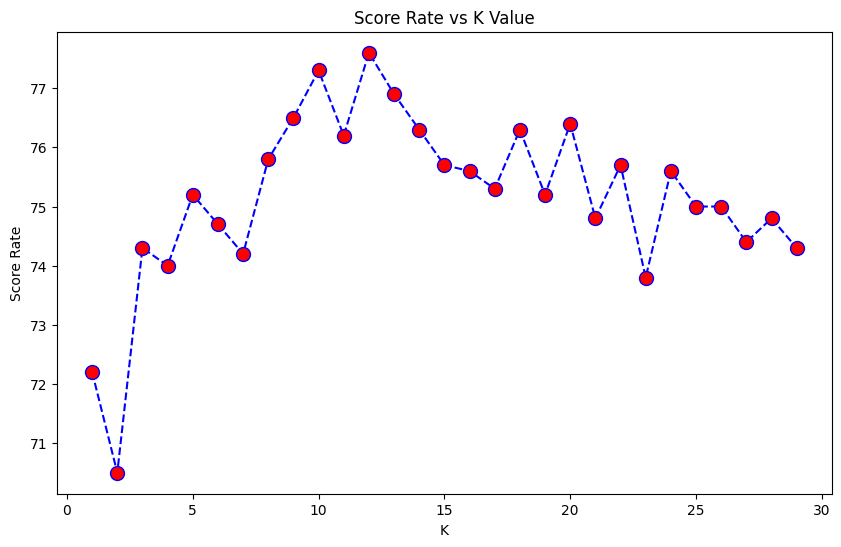

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

score = []

for i in range(1,30):
  knn_cv = KNeighborsClassifier(n_neighbors=i)
  cv_scores = cross_val_score(knn_cv, X, y, cv=5)
  score.append(round((cv_scores.mean()*100), 2))

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Score Rate')
plt.show()

Classification Report do modelo treinado com o melhor valor de k

In [ ]:
knn.fit(x_train, y_train)
print(classification_report(y_test, knn.predict(x_test)))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76       133
           1       0.81      0.78      0.80       167

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300



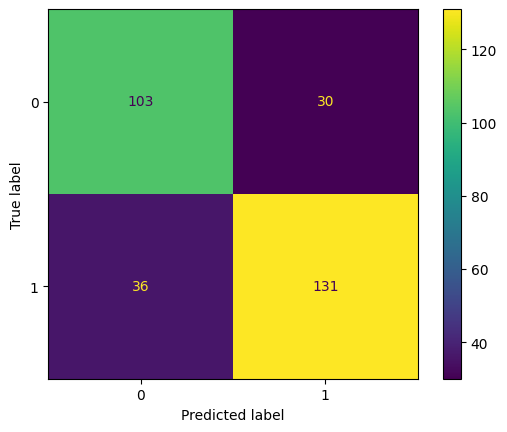

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(knn, x_test, y_test)
plt.show()

#### Dados **Iris**

Ponto extra

In [ ]:
scores_iris = cross_val_score(knn, X_iris, y_iris, cv=5)
scores_iris

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])

In [ ]:
print(round(scores_iris.mean() * 100, 2))

97.33


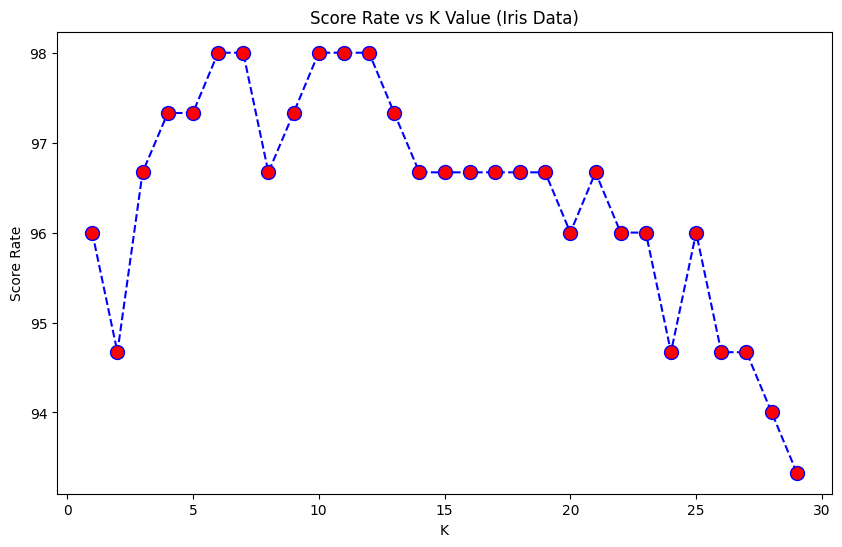

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

score = []

for i in range(1,30):
  knn_cv = KNeighborsClassifier(n_neighbors=i)
  cv_scores = cross_val_score(knn_cv, X_iris, y_iris, cv=5)
  score.append(round((cv_scores.mean()*100), 2))

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs K Value (Iris Data)')
plt.xlabel('K')
plt.ylabel('Score Rate')
plt.show()

Classification Report do modelo treinado com o melhor valor de k

In [ ]:
knn.fit(x_train_i, y_train_i)
print(classification_report(y_test_i, knn.predict(x_test_i)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.89      0.94        19
           2       0.86      1.00      0.92        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



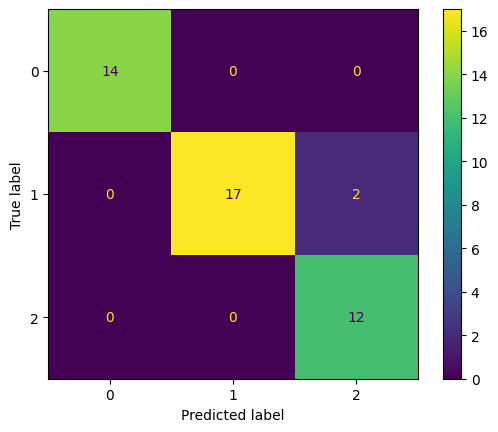

In [ ]:
ConfusionMatrixDisplay.from_estimator(knn, x_test_i, y_test_i)
plt.show()

## Conclusão

Descreva o que você identificou como melhoria ou não da utilização das abordagens do PCA, feature selection e Cross Validation.

A utilização das abordagens de PCA, Feature Selection e Cross Validation mostrou-se fundamental para a otimização dos modelos. Identificou-se que o PCA com 5 componentes obteve uma melhoria real na performance (Accuracy de 0.79 vs 0.78 do modelo original), indicando que a redução de dimensionalidade foi eficaz em remover ruídos sem perder informações essenciais. O Feature Selection via Random Forest no dataset Iris permitiu identificar as variáveis mais relevantes (pétalas), enquanto a Cross Validation assegurou a robustez dos resultados, demonstrando uma excelente capacidade de generalização (97.33% de acurácia média no Iris). Em suma, as técnicas de simplificação do espaço de atributos e validação rigorosa permitiram criar modelos mais eficientes e confiáveis.
